# Two Parks, Three Vacant Lots, and 1,254 Votes

In [1]:
import json, re
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import re

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu, spearmanr

SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLUE, RED, GRAY = "#2a78d6", "#e34948", "#a5a49e"
pd.set_option("display.max_colwidth", 200)
con = duckdb.connect()
for t in ("meetings", "licenses", "votes", "speakers", "incidents", "cannabis"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '../data/db/{t}.parquet'")

def q(sql):
    return con.execute(sql).df()

# full-text index: meeting_id -> complete minutes text (text layer + vision OCR)
_meet = json.loads(Path("../data/meetings.json").read_text())["meetings"]
_sha2mid = {f["sha256"]: mid for mid, m in _meet.items() for f in m["files"]}
_texts = {}
for _tf in Path("../data/interim/text").glob("*.json"):
    _mid = _sha2mid.get(_tf.stem)
    if _mid:
        _texts[_mid] = _texts.get(_mid, "") + " " + " ".join(json.loads(_tf.read_text()))
for _of in Path("../data/interim/ocr").glob("*.txt"):
    _mid = _sha2mid.get(_of.name[:64])
    if _mid:
        _texts[_mid] = _texts.get(_mid, "") + " " + _of.read_text()
_lower = {m: t.lower() for m, t in _texts.items()}
_dates = {m: v["date"] for m, v in _meet.items()}
lower = _lower
dates = _dates
def mentions(term):
    """Meetings where `term` appears, with counts. Case-insensitive."""
    term = term.lower()
    return pd.DataFrame(
        [(m, _dates[m], _lower[m].count(term)) for m in _lower if term in _lower[m]],
        columns=["meeting_id", "date", "n"],
    ).sort_values("date").reset_index(drop=True)

def context(term, meeting_id, width=200, k=5):
    """Verbatim passages around each occurrence of `term` in one meeting."""
    out = []
    for m in re.finditer(re.escape(term.lower()), _lower[meeting_id]):
        s = max(0, m.start() - width)
        out.append(" ".join(_texts[meeting_id][s : m.end() + width].split()))
        if len(out) >= k:
            break
    return out

print(f"{len(_texts)} meetings indexed, {sum(len(t) for t in _texts.values())/1e6:.0f}M chars")
wf = pd.DataFrame(
    [(m, _meet[m]["date"], _lower[m].count("waterfront")) for m in _lower],
    columns=["meeting_id", "date", "wf_mentions"],
)
wf["date"] = pd.to_datetime(wf.date)
wf_meetings = wf[wf.wf_mentions > 0].sort_values("date").reset_index(drop=True)


110 meetings indexed, 31M chars


![Bushwick Inlet Park from the community center's green roof, April 2026: the soccer field in use on the left - and one of the three vacant lots on the right. Photo: author](images/bip_and_lots.jpg)

I moved to Williamsburg in January 2026 and was excited about spending time enjoying the waterfront along the East River. There's a lot to enjoy - the views of the Manhattan skyline, birds chirping, small waves crashing... but there's one thing wrong, the park is neighbored by chainlink fences cordoning off 2 large asphalt lots. I was curious who owned these lots and what the backstory was. Clearly there would be interest in developing waterfront property in one of the hottest neighborhoods in one of the hottest real estate markets.

TLDR: in ten years of waterfront votes from the local Community Board 1 governing North Brooklyn, community turnout never flipped a single one. What it won instead - binding conditions attached to approvals.

## The Backstory

There's a long backstory to the North Brooklyn waterfront. This area used to be local industry and has undergone gentrification as the factories have moved out and the Yuppies moved in. The most important development in the waterfront story was in 2005 then Mayor Bloomberg made a deal to rezone the north Brooklyn waterfront. The plan allowed the building of luxury high rise residential towers and promised the development of a publicly accessible waterfront. Great news! 

But it's been two decades, where's our park?

It's worth noting - the lack of a large accessible park is not without good reason. This area was historically a manufacturing and shipping lane - so the lots are large, the soil is polluted, and there is a mess of broken piers in the water. Also - in a post-Sandy world, any new waterfront development is held to a higher standard of storm proofing. Regardless, the current state of vacant lots is clearly not acceptable. If the residential towers were able to be built - how hard could it be to build a park?

![Navy airplanes over Greenpoint, May 1930. The piers, rail yards, and tank farms below are the land in focus for this article. Photo: [U.S. National Archives](https://commons.wikimedia.org/wiki/File:New_York_-_Brooklyn_-_NARA_-_68145045.jpg), public domain](images/aerial_1930_web.jpg)

It turns out I wasn't the only one frustrated. There are several community organizations focused on different parts of the waterfront: Friends of Bushwick Inlet Park, North Brooklyn Neighbors, North Brooklyn Parks Alliance, Brooklyn Greenway Initiative, Newtown Creek Alliance, Friends of WNYC Transmitter Park. I was energized to learn that there were neighbors who cared about the same problems. I was curious to learn about the activism landscape - who is actually making change happen and who is focused on growing the parks vs building more high-rise towers. I also learned about Brooklyn Community Board 1 (CB1). This is the local advisory board for Williamsburg and Greenpoint - every land use application has to come through it for a public hearing and a recommendation before the city decides.

## Scraping the minutes

Lucky for me, CB1 posts all committee meeting notes on their website. As a data engineer and a curious resident I dove in. I scraped the pdfs and created a dataset to help me get a sense of what questions we could answer about how change happens on the most local level. There is a lot of interesting data in here, but this post will focus on the North Brooklyn waterfront development.

I began by creating a dataset with all 110 meetings, 1,254 votes, and 1,369 speakers. The following analysis will focus on only the 97 meetings where the term 'waterfront' appears.

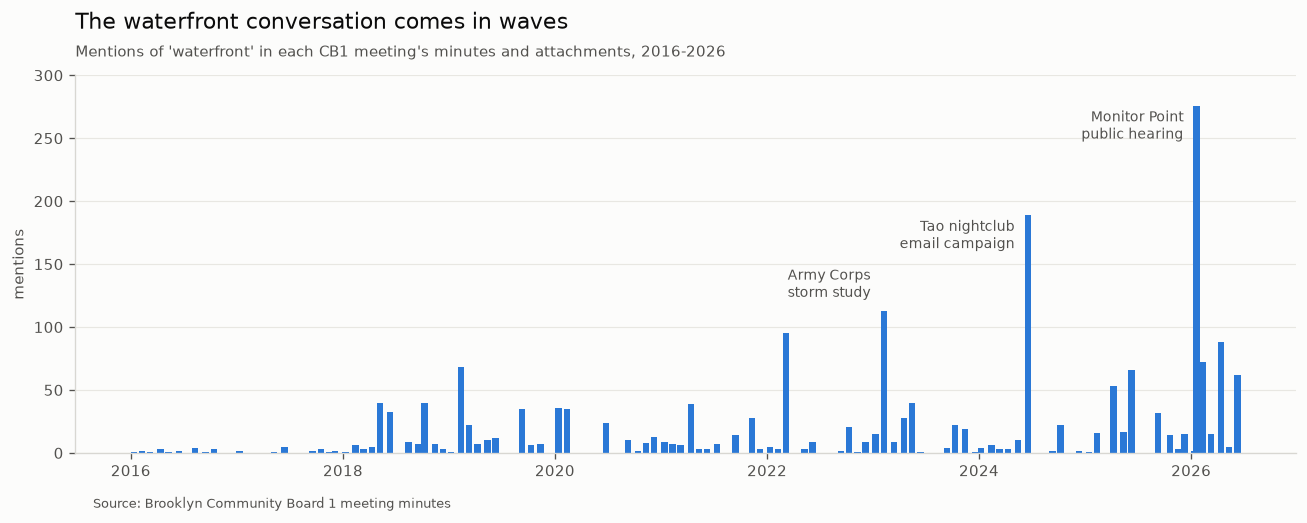

In [2]:
fig, ax = plt.subplots(figsize=(11, 4.2), dpi=120)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.bar(wf_meetings.date, wf_meetings.wf_mentions, width=22, color=BLUE)
for d, v, label in [("2026-01-20", 276, "Monitor Point\npublic hearing"),
                    ("2024-06-18", 189, "Tao nightclub\nemail campaign"),
                    ("2023-02-07", 113, "Army Corps\nstorm study")]:
    ax.annotate(label, (pd.Timestamp(d), v),
                xytext=(-8, 26 if "Army" in label else -2),
                textcoords="offset points", ha="right", va="top",
                fontsize=8.5, color=INK2)
ax.set_ylim(0, 300)
ax.set_ylabel("mentions", fontsize=9, color=INK2)
ax.tick_params(colors=INK2, labelsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#d8d7d2"); ax.spines["bottom"].set_color("#d8d7d2")
ax.grid(axis="y", color="#e8e7e2", lw=0.7); ax.set_axisbelow(True)
ax.set_title("The waterfront conversation comes in waves",
             fontsize=13, color=INK, loc="left", pad=28)
ax.text(0, 1.05, "Mentions of 'waterfront' in each CB1 meeting's minutes and attachments, 2016-2026",
        transform=ax.transAxes, fontsize=9, color=INK2)
fig.text(0.075, -0.02, "Source: Brooklyn Community Board 1 meeting minutes",
         fontsize=8, color=INK2)
plt.tight_layout(); plt.show()

You can see that the term waterfront shows up frequently, with a few spikes in activity.

January 20, 2026 — 276 mentions. This is a public hearing focused exclusively on Monitor Point. The notes are mostly written testimony from individuals and community groups including Veronica Zapasnik, a Polish immigrant who's been in the neighborhood since 1990, and NYSAFAH (the New York State Association for Affordable Housing). Reading the opposition arguments there is a strong emphasis on the rezoning being a violation of previous promises to make the land a waterfront park for all. The frustration is palpable.

June 18, 2024 — 189 mentions. This is the Parks & Waterfront Committee's letter to elected officials covering habitat restoration at the inlet ("birds, insects, oysters"), Marsha P. Johnson State Park, a Sands Park walkthrough request. There is a swarm of emails to the board about the proposal to open a Tao nightclub next to Bushwick Inlet Park, including one template that was re-sent over 100 times.

February 7, 2023 — 113 mentions. The meeting notes include a document from the Army Corps of Engineers discussing plans for storm mitigation in North Brooklyn.

## What does the board actually fight about?

Next I wanted to get a sense of what goes on in these meetings. Do these board meetings ever have contested votes? If so, when - and over what?

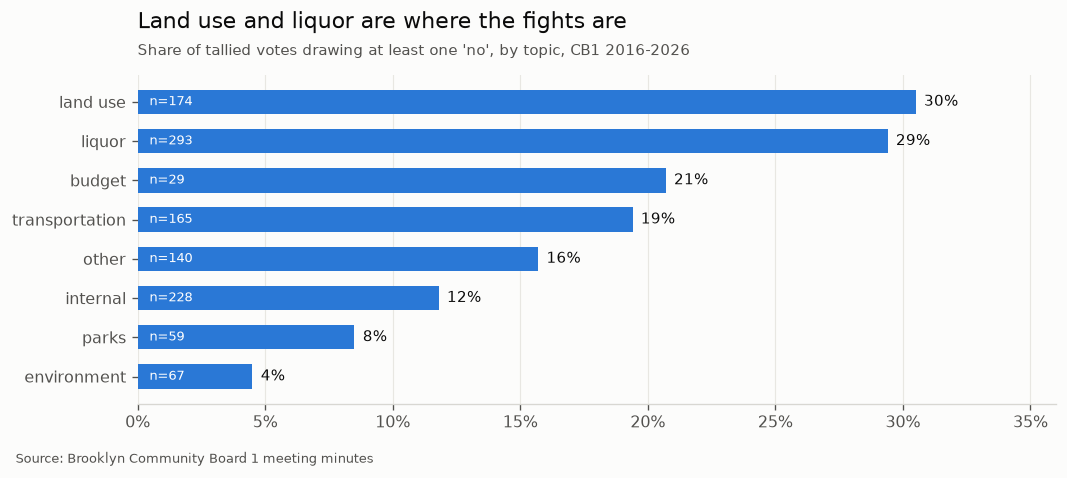

In [3]:
rates = q("""
    SELECT topic_category, count(*) AS n,
           round(avg(CASE WHEN no > 0 THEN 1 ELSE 0 END), 3) AS contested_rate,
           round(stddev_samp(CASE WHEN no > 0 THEN 1 ELSE 0 END), 3) AS std_dev
    FROM votes WHERE yes + no > 0
    GROUP BY 1 ORDER BY contested_rate DESC
""")
NAMES = {"land_use": "land use"}
r = rates.assign(topic=rates.topic_category.map(lambda t: NAMES.get(t, t))).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 3.8), dpi=120)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.barh(r.topic, r.contested_rate, height=0.62, color=BLUE)
for y, (rate, n) in enumerate(zip(r.contested_rate, r.n)):
    ax.annotate(f"{rate:.0%}", (rate, y), xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK)
    ax.annotate(f"n={n}", (0.002, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=7.5, color="#ffffff")
ax.set_xlim(0, 0.36)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.tick_params(colors=INK2, labelsize=9.5)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
ax.grid(axis="x", color="#e8e7e2", lw=0.7); ax.set_axisbelow(True)
ax.set_title("Land use and liquor are where the fights are",
             fontsize=13, color=INK, loc="left", pad=28)
ax.text(0, 1.06, "Share of tallied votes drawing at least one 'no', by topic, CB1 2016-2026",
        transform=ax.transAxes, fontsize=9, color=INK2)
fig.text(0.02, -0.03, "Source: Brooklyn Community Board 1 meeting minutes",
         fontsize=8, color=INK2)
plt.tight_layout(); plt.show()

So clearly votes on parks and environment are not drawing debate. It seems like the real debates happen in these land use votes.

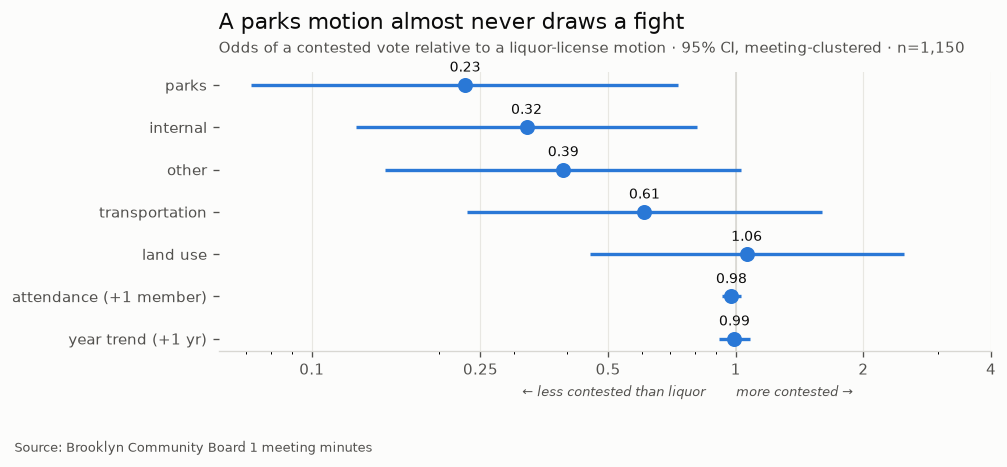

In [4]:
v2 = q("""
    SELECT v.meeting_id, year(m.date) AS yr, v.topic_category,
           m.attendance_count,
           CASE WHEN v.no > 0 THEN 1 ELSE 0 END AS contested
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE v.yes + v.no > 0 AND m.attendance_count IS NOT NULL
""")
v2["topic"] = v2.topic_category.where(
    v2.topic_category.isin(
        ["land_use", "liquor", "transportation", "internal", "parks"]),
    "other")
m2 = smf.logit(
    "contested ~ C(topic, Treatment('liquor')) + attendance_count + I(yr - 2016)",
    data=v2).fit(disp=0, cov_type="cluster", cov_kwds={"groups": v2.meeting_id})
or2 = pd.DataFrame({
    "odds_ratio": np.exp(m2.params),
    "ci_low": np.exp(m2.conf_int()[0]),
    "ci_high": np.exp(m2.conf_int()[1]),
    "p": m2.pvalues,
}).round(3)
LABELS = {
    "C(topic, Treatment('liquor'))[T.parks]": "parks",
    "C(topic, Treatment('liquor'))[T.internal]": "internal",
    "C(topic, Treatment('liquor'))[T.other]": "other",
    "C(topic, Treatment('liquor'))[T.transportation]": "transportation",
    "C(topic, Treatment('liquor'))[T.land_use]": "land use",
    "attendance_count": "attendance (+1 member)",
    "I(yr - 2016)": "year trend (+1 yr)",
}
rows = or2.loc[list(LABELS)].rename(index=LABELS)

fig, ax = plt.subplots(figsize=(8.5, 3.6), dpi=120)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ys = np.arange(len(rows))[::-1]
ax.axvline(1, color="#d8d7d2", lw=1)
ax.hlines(ys, rows.ci_low, rows.ci_high, color=BLUE, lw=2)
ax.plot(rows.odds_ratio, ys, "o", ms=8, color=BLUE, zorder=3)
for y, (name, r) in zip(ys, rows.iterrows()):
    ax.annotate(f"{r.odds_ratio:.2f}", (r.odds_ratio, y), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=8.5, color=INK)
ax.set_yticks(ys, rows.index, fontsize=9.5)
ax.set_xscale("log")
ax.set_xticks([0.1, 0.25, 0.5, 1, 2, 4], ["0.1", "0.25", "0.5", "1", "2", "4"])
ax.tick_params(colors=INK2, labelsize=9)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
ax.grid(axis="x", color="#e8e7e2", lw=0.7); ax.set_axisbelow(True)
ax.set_title("A parks motion almost never draws a fight",
             fontsize=13, color=INK, loc="left", pad=26)
ax.text(0, 1.07, "Odds of a contested vote relative to a liquor-license motion · 95% CI, meeting-clustered · n=1,150",
        transform=ax.transAxes, fontsize=9, color=INK2)
ax.text(0.63, -0.16, "\u2190 less contested than liquor", transform=ax.transAxes,
        ha="right", fontsize=8, color=INK2, style="italic")
ax.text(0.67, -0.16, "more contested \u2192", transform=ax.transAxes,
        ha="left", fontsize=8, color=INK2, style="italic")
fig.text(0.02, -0.06, "Source: Brooklyn Community Board 1 meeting minutes",
         fontsize=8, color=INK2)
plt.tight_layout(); plt.show()

The above plot shows the confidence interval for each type of vote being contested compared to the odds of a liquor license vote being contested. Underlying this analysis is the assumption that votes from one board meeting are independent of votes from another (within a single meeting votes are correlated, which the model accounts for by clustering errors at the meeting level). The liquor license votes were chosen as the baseline due to the ubiquity of this type of vote in every board meeting, high vote count, and dispersion of contested and non-contested votes.

Looking at the park votes - we see that votes on park matters have about a quarter the odds of being contested compared to liquor license votes. Strange - you'd expect that given all the community organization and frustration on the waterfront development there would be more heated votes on these matters. It turns out that most of the debate around the park development actually happens in 'land use' votes and we see those votes are heavily contested as expected.

## Showing up - at the mic and in writing

Next I took a look at these votes considering timeline and community involvement. The reality becomes more clear - land use votes are where the confrontation really takes place. A land use vote is where the board weighs in on whether a real-estate development gets built or the land is opened up to the community.

In [5]:
WF = ("(bushwick inlet|monitor point|river ring|quay|65 commercial|56 quay|"
      "40 quay|waterfront|esplanade|demapp|marsha p|inlet park|fbip|open space)")

wfv = q(f"""
    SELECT v.meeting_id, m.date, v.motion_text, v.topic_category,
           v.yes, v.no, v.abstain, v.outcome, len(v.conditions) AS num_conditions_attached
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE v.topic_category IN ('land_use','parks','environment')
      AND regexp_matches(lower(v.motion_text), '{WF}')
      AND NOT regexp_matches(lower(v.motion_text), 'link5g')
      AND v.yes + v.no > 0
    ORDER BY date
""")
tot = wfv.yes + wfv.no + wfv.abstain
wfv["division"] = (tot - wfv[["yes", "no"]].max(axis=1)) / tot
APP = re.compile(r"application|ulurp|ceqr|proposal|scoping|design|demapp", re.I)
wfv["kind"] = wfv.motion_text.map(
    lambda t: "application" if APP.search(t) else "advocacy")
wfv["date"] = pd.to_datetime(wfv.date)

wfs = q(f"""
    SELECT m.date, s.position FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE regexp_matches(lower(s.topic), '{WF}')
""")
wfs["date"] = pd.to_datetime(wfs.date)
wfv["spk90"] = wfv.date.map(
    lambda d: ((d - wfs.date).dt.days.between(0, 90)).sum())

disp = wfv.sort_values("date").copy()
disp["Meeting"] = disp.date.dt.strftime("%b %Y")
disp["Motion"] = disp.motion_text.str.slice(0, 60).str.strip() + \
    disp.motion_text.str.len().gt(60).map({True: "...", False: ""})
disp["Type"] = disp.kind
disp["Topic"] = disp.topic_category.str.replace("_", " ")
disp["Vote (yes-no-abstain)"] = (disp.yes.astype(str) + "-" + disp.no.astype(str)
                                 + "-" + disp.abstain.astype(str))
disp["Board division"] = (disp.division * 100).round().astype(int).astype(str) + "%"
disp["Conditions attached"] = disp.num_conditions_attached
disp["Speakers, prior 90 days"] = disp.spk90
from IPython.display import HTML
_tbl = disp[["Meeting", "Motion", "Type", "Vote (yes-no-abstain)",
             "Board division", "Conditions attached", "Speakers, prior 90 days"]] \
    .to_html(index=False, border=0, classes=["table", "table-sm", "table-striped"])
HTML("<details><summary><strong>The 26 votes behind the chart</strong> "
     "(click to expand)</summary>" + _tbl + "</details>")

Meeting,Motion,Type,Vote (yes-no-abstain),Board division,Conditions attached,"Speakers, prior 90 days"
Jun 2016,Motion to have the Parks Department move forward with the Bu...,advocacy,39-0-0,0%,0,1
Jun 2019,Send a letter to the Parks Department and EDC requesting air...,advocacy,36-0-0,0%,0,0
Nov 2019,Motion to send a letter of support for the Friends of Bushwi...,advocacy,38-0-0,0%,0,0
Feb 2020,Motion to support the committee's recommendation to reject t...,application,33-0-0,0%,6,0
Jun 2020,Approval of the Parks & Waterfront Committee's Report RE: Re...,application,28-0-0,0%,0,0
Oct 2020,Motion to send a letter requesting that the Parks Department...,advocacy,29-0-0,0%,0,2
Jan 2021,Support the Parks & Waterfront Committee recommendation rega...,application,47-0-0,0%,1,11
Jan 2021,Support the Parks & Waterfront Committee recommendation rega...,advocacy,47-0-0,0%,1,11
Feb 2021,Send letter to NYS Parks and state elected officials regardi...,advocacy,30-0-0,0%,0,12
Mar 2021,Support the Parks & Waterfront Committee's amended resolutio...,application,30-0-0,0%,4,19


In [6]:
import json
from pathlib import Path

_meet = json.loads(Path("../data/meetings.json").read_text())["meetings"]
BOUND = re.compile(
    r"From: [A-Z][A-Za-z .\u2019'-]{3,40}? Sent: |"
    r"Dear (?:Chair|Chairperson|Community Board|CB ?1|Members|Board|Mr\.|Ms\.|"
    r"Sir|Madam|District Manager)|To Whom It May Concern", re.I)
WFC = re.compile(r"bushwick inlet|monitor point|river ring|quay|65 commercial|"
                 r"waterfront|esplanade|demapp|inlet park|marsha p", re.I)

_ocr = {}
for _of in Path("../data/interim/ocr").glob("*.txt"):
    sha, p = _of.stem.rsplit("-p", 1)
    _ocr.setdefault(sha, []).append((int(p), _of))

rows = []
for mid, m in _meet.items():
    att = ""
    for f in m["files"]:
        sha = f["sha256"]
        sf = Path(f"../data/interim/segments/{sha}.json")
        if not sf.exists():
            continue
        body = set(json.loads(sf.read_text())["body_pages"])
        tp = Path(f"../data/interim/text/{sha}.json")
        pages = json.loads(tp.read_text()) if tp.exists() else []
        att += " ".join(p for i, p in enumerate(pages) if i not in body)
        for pno, of in _ocr.get(sha, []):
            if pno not in body:
                att += " " + of.read_text()
    t = " ".join(att.split())
    idxs = [b.start() for b in BOUND.finditer(t)]
    wf_items = 0
    for j, st in enumerate(idxs):
        end = idxs[j + 1] if j + 1 < len(idxs) else min(st + 1500, len(t))
        if WFC.search(t[st:end]):
            wf_items += 1
    rows.append({"date": pd.Timestamp(m["date"]), "n_virtual": wf_items})
corr_pm = pd.DataFrame(rows).query("n_virtual > 0").sort_values("date")
print(f"{corr_pm.n_virtual.sum()} waterfront written comments across "
      f"{len(corr_pm)} meetings (packets include correspondence from ~2022)")

355 waterfront written comments across 42 meetings (packets include correspondence from ~2022)


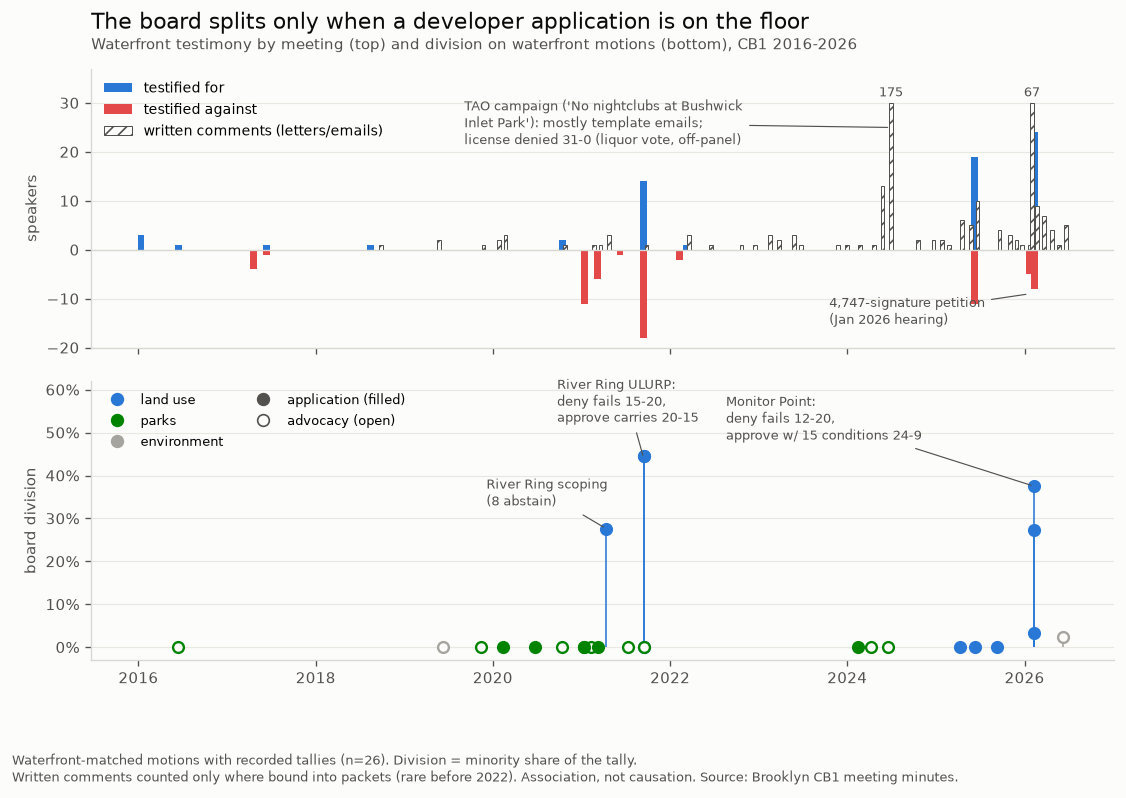

In [7]:
per_meet = q(f"""
    SELECT m.date,
           count(*) FILTER (s.position = 'for') AS n_for,
           count(*) FILTER (s.position = 'against') AS n_against
    FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE regexp_matches(lower(s.topic), '{WF}')
    GROUP BY 1 ORDER BY 1
""")
per_meet["date"] = pd.to_datetime(per_meet.date)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 6.4), dpi=120, sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12})
fig.patch.set_facecolor(SURFACE)
W = 28  # bar width, days
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color("#d8d7d2")
    ax.spines["bottom"].set_color("#d8d7d2")
    ax.tick_params(colors=INK2, labelsize=9)

ax1.bar(per_meet.date, per_meet.n_for, width=W, color=BLUE, label="testified for")
ax1.bar(per_meet.date, -per_meet.n_against, width=W, color=RED,
        label="testified against")
VBAR = corr_pm.set_index("date").n_virtual
ax1.bar(VBAR.index + pd.Timedelta(days=11), VBAR.clip(upper=30), width=W * 0.55,
        facecolor=SURFACE, edgecolor=INK2, hatch="///", lw=0.6,
        label="written comments (letters/emails)")
for d, nv in VBAR[VBAR > 30].items():
    ax1.annotate(f"{nv}", (d + pd.Timedelta(days=11), 30.7), ha="center",
                 va="bottom", fontsize=8, color=INK2)
ax1.set_ylim(-20, 37)
ax1.axhline(0, color="#d8d7d2", lw=0.8)
ax1.set_ylabel("speakers", fontsize=9, color=INK2)
ax1.legend(loc="upper left", frameon=False, fontsize=8.5)
ax1.grid(axis="y", color="#e8e7e2", lw=0.7)
ax1.set_axisbelow(True)
ax1.annotate("4,747-signature petition\n(Jan 2026 hearing)",
             (pd.Timestamp("2026-01-20"), -9), xytext=(-120, -18),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax1.annotate("TAO campaign ('No nightclubs at Bushwick\nInlet Park'): mostly template emails;\nlicense denied 31-0 (liquor vote, off-panel)",
             (pd.Timestamp("2024-06-29"), 25), xytext=(-256, -10),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax1.set_title("The board splits only when a developer application is on the floor",
              fontsize=13, color=INK, loc="left", pad=24)
ax1.text(0, 1.07, "Waterfront testimony by meeting (top) and division on waterfront motions (bottom), CB1 2016-2026",
         transform=ax1.transAxes, fontsize=9, color=INK2)

GREEN = "#008300"
TOPIC_COLOR = {"land_use": BLUE, "parks": GREEN, "environment": GRAY}
for (topic, kind), g in wfv.groupby(["topic_category", "kind"]):
    color = TOPIC_COLOR[topic]
    face = color if kind == "application" else SURFACE
    ax2.vlines(g.date, 0, g.division, color=color, lw=1.2, alpha=0.8)
    ax2.scatter(g.date, g.division, s=42, facecolor=face, edgecolor=color,
                lw=1.4, zorder=3)
ax2.set_ylabel("board division", fontsize=9, color=INK2)
ax2.set_ylim(-0.03, 0.62)
ax2.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
from matplotlib.lines import Line2D
handles = [
    Line2D([], [], marker="o", ls="", mfc=BLUE, mec=BLUE, ms=7, label="land use"),
    Line2D([], [], marker="o", ls="", mfc=GREEN, mec=GREEN, ms=7, label="parks"),
    Line2D([], [], marker="o", ls="", mfc=GRAY, mec=GRAY, ms=7, label="environment"),
    Line2D([], [], marker="o", ls="", mfc=INK2, mec=INK2, ms=7, label="application (filled)"),
    Line2D([], [], marker="o", ls="", mfc=SURFACE, mec=INK2, ms=7, label="advocacy (open)"),
]
ax2.legend(handles=handles, loc="upper left", frameon=False, fontsize=8, ncol=2)
ax2.grid(axis="y", color="#e8e7e2", lw=0.7)
ax2.set_axisbelow(True)
ax2.annotate("River Ring scoping\n(8 abstain)", (pd.Timestamp("2021-04-13"), 0.276),
             xytext=(-72, 14), textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax2.annotate("River Ring ULURP:\ndeny fails 15-20,\napprove carries 20-15",
             (pd.Timestamp("2021-09-14"), 0.44), xytext=(-52, 22),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax2.annotate("Monitor Point:\ndeny fails 12-20,\napprove w/ 15 conditions 24-9",
             (pd.Timestamp("2026-02-10"), 0.375), xytext=(-185, 28),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
fig.text(0.065, -0.01,
         "Waterfront-matched motions with recorded tallies (n=26). Division = minority share of the tally.\n"
         "Written comments counted only where bound into packets (rare before 2022). "
         "Association, not causation. Source: Brooklyn CB1 meeting minutes.",
         fontsize=8, color=INK2, va="top")
plt.show()

The above charts show the community involvement (top) and the board's votes (bottom). From 2016 to 2020 there's minimal community involvement and zero contentious votes - waterfront advocacy motions pass unanimously, year after year. CB1 vote division shows up twice in the voting record: the River Ring cluster (2021) and Monitor Point (2026). And both of these votes are clearly correlated with testimony spikes in the top chart.

The chart also shows 2 more interesting conclusions. First, turnout is not one-sided: at the Monitor Point vote in February 2026 the testimony ran 24 in favor vs 8 against - union members turned out for the project - while a 4,747-signature petition ran against it. "Community involvement" was on both sides of the room. Second, written testimony grows over time. The hatched bars in the top chart show the written testimony. At the January 2026 hearing only 5 people spoke at the mic, but the packet contains 67 written comments. Over time we start seeing more community involvement via this channel. It's hard to say if this is a real data point or just an artifact of the board minutes including more written testimony over time.

The 2024 Tao nightclub fight is missing from the bottom chart. This was actually a liquor license vote and the chart only tracks land use. This vote still deserves a callout because it's the community's one outright win in the dataset. The community showed up with 105 emails and ten speakers at the meeting. The board denied the license 31-0 that same night. The smallest, most specific ask on the ballot was the one that fully converted.

It's important to recognize that turnout isn't a pancea. River Ring and Monitor Point were both approved despite community turnout. The petition didn't flip a vote. However, the large turnout coincides with (a) recorded splits - every member's name on a roll call - and (b) conditions attached to the approval. For example, Monitor Point passed with 15 attached conditions, and you can trace individual conditions back to specific community asks - the esplanade width, the museum's occupancy certificate, the maintenance money doubling.

## What I learned

The board's voted with the community, unanimously, for a decade, and the park still didn't get built. In order to make change happen, the most important meetings are the Land Use hearings. Volume of community involvment alone doesn't move the needle - specific requests backed by the community do.

So that's where I'll focus my attention - land use hearings, with specific asks on developing the vacant park land.

![One of the fenced-off lots at the park's edge, July 2026: cracked asphalt, weeds, and a skyline view going unused. Photo: author](images/lots_fence.jpg)

## Methodology

The dataset comes from the PDF meeting minutes CB1 posts publicly - 138 files covering 110 meetings from 2016 to 2026, about 22,000 pages. I extracted structured records (votes, liquor licenses, public speakers) with a custom ETL pipeline leveraging LLMs via AWS Bedrock to scan and extract data points. I hand-verified a subset of data points from three sample meetings against the original PDFs: vote tallies matched 38 of 38, license records 144 of 144, and speaker recall was 97%. Every extracted record keeps a verbatim quote from the source PDF, so any claim in this post can be traced back to a page. One extraction gap surfaced during this analysis - the September 2021 roll-call section, including the River Ring votes, had been misfiled as an attachment - and was recovered by hand from the minutes text, with the fix documented in the dataset.

Three disclaimers:
1. The waterfront vote panel is small - 26 votes, and one night (February 2026) contributes three of them.
2. Everything stated above is association, not causation: big projects generate both turnout and division, and this data can't say which causes which.
3. And written comments only appear in the record from 2022, when the board office started binding correspondence into the minutes, so the written channel can't be compared across that line.

Code and data will be linked here when the repo goes public.